SAGE-GraphTransformer, implemented below as a CircuitSAGETransformer using PyTorch Geometric SAGEConv + TransformerConv. PyGs TransformerConv supports multi-head attention and edge attributes through edge_dim, which lets us use your fan_out edge metadata directly.

Below is a complete independent notebook script. It reads only:

- nodes_enhanced.csv
- edges_enhanced.csv

It then performs a netlist-level train/validation/test split, builds joint node-classification graphs, appends the same style of relational features as your h-GAT code, trains the SAGE-Transformer model, and prints training accuracy, validation accuracy, test accuracy, classification report, and confusion matrix.

/home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_geometric/typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: /home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_cluster/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
/home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_geometric/typing.py:113: UserWarning: An issue occurred while importing 'torch-spline-

Device: cpu
Classes: ['bridging', 'clean', 'glitch', 'stuck_at']
Number of classes: 4
Clean class index: 1
Gate vocabulary: ['and', 'nand', 'nor', 'not', 'or', 'other', 'xor']
Gate one-hot dimension: 7

Total netlists: 30
Train netlists: 24
Test netlists:  6

Train netlists (24):
-------------------
01. Priority.v
02. adder.v
03. arbiter.v
04. bar.v
05. c1355.v
06. c17.v
07. c1908.v
08. c2670.v
09. c499.v
10. c5315.v
11. c6288.v
12. c7552.v
13. c880.v
14. ctrl.v
15. div.v
16. i2c.v
17. int2float.v
18. log2.v
19. max.v
20. multiplier.v
21. router.v
22. sin.v
23. square.v
24. voter.v

Test netlists (6):
------------------
01. c3540.v
02. c432.v
03. cavlc.v
04. dec.v
05. memctrl.v
06. sqrt.v

Split sanity check:
-------------------
Train and Test overlap: []

No overlap found between train/test netlists.

Built graphs: train=24, test=6
Initial input dimension: 18

Test graph netlists and node counts:
------------------------------------
01. sqrt.v | nodes=37097
02. cavlc.v | nodes=1541
03

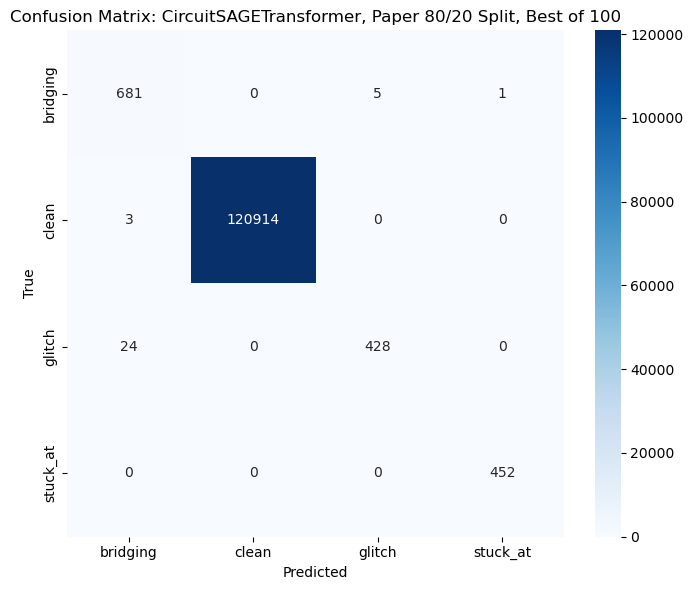


Saved checkpoint to: circuit_sage_transformer_paper_protocol_80_20_100epochs.pt


In [1]:
# ============================================================
# Paper-protocol CircuitSAGETransformer
# for Fault Detection from Enhanced CSVs
#
# Inputs:
#   nodes_enhanced.csv
#   edges_enhanced.csv
#
# Task:
#   Node-level 4-class classification:
#   clean, bridging, glitch, stuck_at
#
# Paper-protocol refinement:
#   - 80/20 train/test split by netlist_file
#   - no separate validation split
#   - train for 100 epochs
#   - learning rate = 7e-4
#   - dropout = 0.4
#   - hidden dimension = 64
#   - train-only normalization
#   - paper-style inverse-frequency class weights
#   - best model selected by lowest monitored test loss,
#     matching the original paper-code style
#   - test netlist names are printed explicitly
#
# Model:
#   Hardware-security-inspired SAGE + Graph Transformer:
#       - SAGEConv local inductive aggregation
#       - edge-aware TransformerConv layers
#       - edge attributes include fanout and direction flags
#       - node-level classifier
# ============================================================


# ============================================================
# 1. Imports and configuration
# ============================================================

import os
import re
import math
import random
import warnings
from pathlib import Path
from typing import List

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

try:
    from torch_geometric.data import Data
    from torch_geometric.loader import DataLoader
    from torch_geometric.nn import SAGEConv, TransformerConv
except Exception as e:
    raise RuntimeError(
        "PyTorch Geometric is required. Install a version compatible with your "
        "PyTorch/CUDA setup before running this notebook."
    ) from e


# -------------------------
# Reproducibility
# -------------------------
SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)


# -------------------------
# File paths
# -------------------------
NODES_FILE = "nodes_enhanced.csv"
EDGES_FILE = "edges_enhanced.csv"


# -------------------------
# Paper-style split settings
# -------------------------
TEST_RATIO = 0.20

# Paper-code behavior:
# prefer clean topology if available; otherwise fall back to union.
EDGE_MODE = "clean"       # choices: "clean", "union"

# Add reverse edges for bidirectional message passing.
ADD_REVERSE_EDGES = True


# -------------------------
# Paper-style training hyperparameters
# -------------------------
EPOCHS = 100
LR = 7e-4
WEIGHT_DECAY = 5e-4
BATCH_SIZE = 1

HID = 64
DROPOUT = 0.4


# -------------------------
# CircuitSAGETransformer settings
# -------------------------
TRANSFORMER_HEADS = 4


# -------------------------
# Balanced node sampling during training
# -------------------------
MAX_FAULT_NODES_PER_CLASS_PER_GRAPH = 512
CLEAN_TO_FAULT_RATIO = 1.0

PRINT_EVERY = 5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


# ============================================================
# 2. Load enhanced CSV files
# ============================================================

nodes_df = pd.read_csv(NODES_FILE)
edges_df = pd.read_csv(EDGES_FILE)

required_node_cols = [
    "netlist_file", "fault_type", "node_id", "gate_type", "label",
    "in_degree", "out_degree", "total_degree", "path_depth",
    "CC0_exact", "CC1_exact", "CO_exact", "dist_to_PO",
    "fanout", "fanout_norm", "gate_delay",
]

required_edge_cols = [
    "netlist_file", "fault_type", "src_node", "dst_node",
]

for c in required_node_cols:
    if c not in nodes_df.columns:
        raise ValueError(f"Missing required node column: {c}")

for c in required_edge_cols:
    if c not in edges_df.columns:
        raise ValueError(f"Missing required edge column: {c}")

if "fan_out" not in edges_df.columns:
    if "fanout" in edges_df.columns:
        edges_df = edges_df.rename(columns={"fanout": "fan_out"})
    else:
        warnings.warn("edges_enhanced.csv has no fan_out column. Using fan_out=1.0.")
        edges_df["fan_out"] = 1.0


# -------------------------
# String cleanup
# -------------------------
for c in ["netlist_file", "fault_type", "node_id", "gate_type"]:
    nodes_df[c] = nodes_df[c].astype(str)

for c in ["netlist_file", "fault_type", "src_node", "dst_node"]:
    edges_df[c] = edges_df[c].astype(str)


# -------------------------
# Numeric cleanup
# -------------------------
base_num_cols = [
    "in_degree",
    "out_degree",
    "total_degree",
    "path_depth",
    "CC0_exact",
    "CC1_exact",
    "CO_exact",
    "dist_to_PO",
    "fanout",
    "fanout_norm",
    "gate_delay",
]

for c in base_num_cols:
    nodes_df[c] = (
        pd.to_numeric(nodes_df[c], errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
        .astype(np.float32)
    )

nodes_df["label"] = (
    pd.to_numeric(nodes_df["label"], errors="coerce")
    .fillna(0)
    .astype(int)
)

edges_df["fan_out"] = (
    pd.to_numeric(edges_df["fan_out"], errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .fillna(1.0)
    .astype(np.float32)
)


# ============================================================
# 3. Encode class labels and gate types
# ============================================================

le = LabelEncoder()
nodes_df["fault_cls"] = le.fit_transform(nodes_df["fault_type"])

class_names = list(le.classes_)
class_to_idx = {c: i for i, c in enumerate(class_names)}
num_classes = len(class_names)

if "clean" not in class_to_idx:
    raise ValueError(
        "The fault_type column must contain a 'clean' class for joint graph construction."
    )

clean_idx = class_to_idx["clean"]

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Clean class index:", clean_idx)


def canonical_gate_type(gate_type: str) -> str:
    """
    Paper-compatible compact gate vocabulary.

    Pseudo-fault gate names are mapped to 'other' to reduce direct leakage
    from names such as sa0, sa1, bridge, and glitch.
    """
    s = str(gate_type).strip().lower()
    s = re.sub(r"[^a-z0-9_]+", "_", s)

    # Avoid direct leakage from pseudo-fault gate names.
    if s in {"sa0", "sa1", "bridge", "glitch"}:
        return "other"
    if s.startswith("sa0") or s.startswith("sa1"):
        return "other"
    if s.startswith("br_") or s.startswith("bridge"):
        return "other"
    if s.startswith("gl_") or s.startswith("glitch"):
        return "other"

    # Common logic normalizations.
    if s.startswith("nand"):
        return "nand"
    if s.startswith("and"):
        return "and"
    if s.startswith("nor"):
        return "nor"
    if s.startswith("or"):
        return "or"
    if s.startswith("xnor"):
        return "xnor"
    if s.startswith("xor"):
        return "xor"
    if s.startswith("inv") or s.startswith("not"):
        return "not"
    if s.startswith("buf") or s.startswith("buff"):
        return "buf"
    if s in {"pi", "po"}:
        return s

    return "other"


nodes_df["gate_canon"] = nodes_df["gate_type"].map(canonical_gate_type)

gate_vocab = sorted(nodes_df["gate_canon"].unique().tolist())
if "other" not in gate_vocab:
    gate_vocab.append("other")
gate_vocab = sorted(gate_vocab)

g2i = {g: i for i, g in enumerate(gate_vocab)}
GATE_DIM = len(gate_vocab)

print("Gate vocabulary:", gate_vocab)
print("Gate one-hot dimension:", GATE_DIM)


# ============================================================
# 4. Paper-style 80/20 netlist-level train/test split
# ============================================================

# Use drop_duplicates order, matching the paper-code scripts.
netlists = nodes_df["netlist_file"].drop_duplicates().values

if len(netlists) < 4:
    raise ValueError(
        f"Only {len(netlists)} netlists found. Need at least 4 for train/test split."
    )

train_nets, test_nets = train_test_split(
    netlists,
    test_size=TEST_RATIO,
    random_state=SEED,
    shuffle=True,
)

print(f"\nTotal netlists: {len(netlists)}")
print(f"Train netlists: {len(train_nets)}")
print(f"Test netlists:  {len(test_nets)}")


def print_split_netlists(split_name, netlist_array):
    netlist_list = sorted([str(x) for x in netlist_array])

    print(f"\n{split_name} netlists ({len(netlist_list)}):")
    print("-" * (len(split_name) + 14))

    for i, nf in enumerate(netlist_list, start=1):
        print(f"{i:02d}. {nf}")


print_split_netlists("Train", train_nets)
print_split_netlists("Test", test_nets)

train_set = set(map(str, train_nets))
test_set = set(map(str, test_nets))

print("\nSplit sanity check:")
print("-------------------")
print("Train and Test overlap:", sorted(train_set & test_set))

assert len(train_set & test_set) == 0, "Train and test netlists overlap!"

print("\nNo overlap found between train/test netlists.")


# Compatibility placeholders in case another helper cell expects val_nets/val_graphs.
# This notebook intentionally follows the paper's train/test-only protocol.
val_nets = np.array([], dtype=object)
val_graphs = []


# ============================================================
# 5. Build joint node-classification graphs
# ============================================================

def select_edges_for_netlist(nf: str) -> pd.DataFrame:
    """
    Return an edge DataFrame for one netlist.

    EDGE_MODE='clean':
        Use clean topology if available. This mirrors the original
        paper-code style. Fall back to union if clean topology is unavailable.

    EDGE_MODE='union':
        Uses all clean/faulted edges and deduplicates by src/dst.
    """
    all_e = edges_df[edges_df["netlist_file"] == nf]

    if EDGE_MODE == "clean":
        clean_e = all_e[all_e["fault_type"] == "clean"]
        use_e = clean_e if not clean_e.empty else all_e
    elif EDGE_MODE == "union":
        use_e = all_e
    else:
        raise ValueError("EDGE_MODE must be either 'clean' or 'union'.")

    if use_e.empty:
        return use_e

    use_e = (
        use_e.groupby(["src_node", "dst_node"], as_index=False)["fan_out"]
        .mean()
    )
    return use_e


def build_joint_graphs(nets):
    """
    Build one joint graph per netlist_file.

    Node set:
        Union of clean and faulted nodes.

    Labels:
        Start all nodes as clean.
        For non-clean fault_type rows where label==1, assign that node to
        its fault class.

    Features:
        Gate one-hot + base enhanced numeric features.
        For normal nodes, prefer clean-row features.
        For pseudo-fault nodes, use the label==1 fault row.
    """
    graphs = []

    for nf in nets:
        nd_sub = nodes_df[nodes_df["netlist_file"] == nf].copy()
        if nd_sub.empty:
            continue

        node_ids = sorted(nd_sub["node_id"].unique().tolist())
        id2idx = {nid: i for i, nid in enumerate(node_ids)}
        N = len(node_ids)

        clean_rows = (
            nd_sub[nd_sub["fault_type"] == "clean"]
            .drop_duplicates("node_id", keep="first")
            .set_index("node_id")
        )

        fault_label_rows = (
            nd_sub[(nd_sub["fault_type"] != "clean") & (nd_sub["label"] == 1)]
            .drop_duplicates("node_id", keep="first")
            .set_index("node_id")
        )

        first_rows = (
            nd_sub.drop_duplicates("node_id", keep="first")
            .set_index("node_id")
        )

        clean_set = set(clean_rows.index)
        fault_label_set = set(fault_label_rows.index)

        # Node features.
        x_gate = np.zeros((N, GATE_DIM), dtype=np.float32)
        x_num = np.zeros((N, len(base_num_cols)), dtype=np.float32)

        for i, nid in enumerate(node_ids):
            if nid in clean_set:
                row = clean_rows.loc[nid]
            elif nid in fault_label_set:
                row = fault_label_rows.loc[nid]
            else:
                row = first_rows.loc[nid]

            gate = canonical_gate_type(row["gate_type"])
            gate_idx = g2i.get(gate, g2i["other"])
            x_gate[i, gate_idx] = 1.0

            x_num[i, :] = row[base_num_cols].astype(np.float32).values

        x = np.concatenate([x_gate, x_num], axis=1)

        # Labels.
        y = np.full(N, fill_value=clean_idx, dtype=np.int64)

        faulty_rows = nd_sub[
            (nd_sub["fault_type"] != "clean") &
            (nd_sub["label"] == 1)
        ]

        for _, r in faulty_rows.iterrows():
            nid = r["node_id"]
            ft = r["fault_type"]

            if nid in id2idx and ft in class_to_idx:
                y[id2idx[nid]] = class_to_idx[ft]

        # Directed edges and simple edge features.
        e_use = select_edges_for_netlist(nf)

        src_list, dst_list, edge_attrs = [], [], []

        if not e_use.empty:
            max_fanout = float(max(e_use["fan_out"].max(), 1.0))

            for _, erow in e_use.iterrows():
                s = erow["src_node"]
                d = erow["dst_node"]

                if s not in id2idx or d not in id2idx:
                    continue

                fan = float(erow["fan_out"])
                fan = max(fan, 0.0)

                src_list.append(id2idx[s])
                dst_list.append(id2idx[d])

                edge_attrs.append([
                    math.log1p(fan),
                    fan / max_fanout,
                ])

        if len(src_list) > 0:
            edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
            edge_attr = torch.tensor(edge_attrs, dtype=torch.float32)
        else:
            edge_index = torch.empty((2, 0), dtype=torch.long)
            edge_attr = torch.empty((0, 2), dtype=torch.float32)

        data = Data(
            x=torch.tensor(x, dtype=torch.float32),
            edge_index=edge_index,
            edge_attr=edge_attr,
            y=torch.tensor(y, dtype=torch.long),
        )

        data.netlist_file = nf
        graphs.append(data)

    return graphs


train_graphs = build_joint_graphs(train_nets)
test_graphs = build_joint_graphs(test_nets)

print(f"\nBuilt graphs: train={len(train_graphs)}, test={len(test_graphs)}")
print("Initial input dimension:", train_graphs[0].x.size(1))

print("\nTest graph netlists and node counts:")
print("------------------------------------")
for i, g in enumerate(test_graphs, start=1):
    print(f"{i:02d}. {g.netlist_file} | nodes={g.num_nodes}")

test_graph_names = set(str(g.netlist_file) for g in test_graphs)
test_net_names = set(map(str, test_nets))

assert test_graph_names <= test_net_names, "Some test graphs are not from test_nets."

print("\nAll test graphs were built only from test_nets.")


# ============================================================
# 6. Append relational features, as in the paper pipeline
# ============================================================

NUM_START = GATE_DIM
base_idx = {c: NUM_START + i for i, c in enumerate(base_num_cols)}

idx_CC0 = base_idx["CC0_exact"]
idx_CC1 = base_idx["CC1_exact"]
idx_CO = base_idx["CO_exact"]
idx_path = base_idx["path_depth"]
idx_distPO = base_idx["dist_to_PO"]


def build_adj_lists(edge_index: torch.Tensor, N: int):
    out_adj = [[] for _ in range(N)]
    in_adj = [[] for _ in range(N)]

    if edge_index.numel() == 0:
        return in_adj, out_adj

    src = edge_index[0].cpu().numpy().tolist()
    dst = edge_index[1].cpu().numpy().tolist()

    for s, d in zip(src, dst):
        out_adj[s].append(d)
        in_adj[d].append(s)

    return in_adj, out_adj


def neighbor_mean(arr: np.ndarray, adj):
    out = np.zeros(len(adj), dtype=np.float32)

    for u, neigh in enumerate(adj):
        if neigh:
            out[u] = float(np.mean(arr[neigh]))
        else:
            out[u] = float(arr[u])

    return out


def k_hop_unique_counts(adj, K: int = 3):
    """
    Count unique nodes reachable within <=K hops for every node.
    """
    N = len(adj)
    counts = np.zeros(N, dtype=np.float32)

    for u in range(N):
        seen = set()
        frontier = [u]

        for _ in range(K):
            nxt = []

            for v in frontier:
                for w in adj[v]:
                    if w != u and w not in seen:
                        seen.add(w)
                        nxt.append(w)

            frontier = nxt
            if not frontier:
                break

        counts[u] = float(len(seen))

    return counts


def count_reachable_targets(u: int, targets: set, adj, K: int = 3):
    seen = set()
    frontier = [u]

    for _ in range(K):
        nxt = []

        for v in frontier:
            for w in adj[v]:
                if w not in seen:
                    seen.add(w)
                    nxt.append(w)

        frontier = nxt
        if not frontier:
            break

    return float(sum(1 for w in seen if w in targets))


def append_relational_features(data: Data) -> Data:
    """
    Append 20 relational features:
      - predecessor/successor means of CC0, CC1, CO
      - deltas from those means
      - 1/2/3-hop fan-in/fan-out counts
      - 3-hop PI-like ancestor and PO-like descendant counts

    These are computed on the directed edge_index before optional reverse
    message-passing edges are added.
    """
    x = data.x.clone().float()
    N = x.size(0)

    in_adj, out_adj = build_adj_lists(data.edge_index, N)

    cc0 = x[:, idx_CC0].cpu().numpy()
    cc1 = x[:, idx_CC1].cpu().numpy()
    co = x[:, idx_CO].cpu().numpy()

    # Neighbor means.
    cc0_in_mean = neighbor_mean(cc0, in_adj)
    cc1_in_mean = neighbor_mean(cc1, in_adj)
    co_in_mean = neighbor_mean(co, in_adj)

    cc0_out_mean = neighbor_mean(cc0, out_adj)
    cc1_out_mean = neighbor_mean(cc1, out_adj)
    co_out_mean = neighbor_mean(co, out_adj)

    # Deltas.
    cc0_in_delta = cc0 - cc0_in_mean
    cc1_in_delta = cc1 - cc1_in_mean
    co_in_delta = co - co_in_mean

    cc0_out_delta = cc0 - cc0_out_mean
    cc1_out_delta = cc1 - cc1_out_mean
    co_out_delta = co - co_out_mean

    # K-hop counts.
    in_k1 = np.array([len(in_adj[u]) for u in range(N)], dtype=np.float32)
    out_k1 = np.array([len(out_adj[u]) for u in range(N)], dtype=np.float32)

    in_k2 = k_hop_unique_counts(in_adj, K=2)
    out_k2 = k_hop_unique_counts(out_adj, K=2)

    in_k3 = k_hop_unique_counts(in_adj, K=3)
    out_k3 = k_hop_unique_counts(out_adj, K=3)

    # PI-like and PO-like detection from already-computed features.
    path = x[:, idx_path].cpu().numpy()
    dist_po = x[:, idx_distPO].cpu().numpy()

    pi_nodes = set(np.where(path == path.min())[0].tolist())
    po_nodes = set(np.where(dist_po == 0)[0].tolist())

    pi_anc3 = np.zeros(N, dtype=np.float32)
    po_des3 = np.zeros(N, dtype=np.float32)

    for u in range(N):
        pi_anc3[u] = count_reachable_targets(u, pi_nodes, in_adj, K=3)
        po_des3[u] = count_reachable_targets(u, po_nodes, out_adj, K=3)

    rel_stack = np.stack([
        cc0_in_mean, cc1_in_mean, co_in_mean,
        cc0_out_mean, cc1_out_mean, co_out_mean,
        cc0_in_delta, cc1_in_delta, co_in_delta,
        cc0_out_delta, cc1_out_delta, co_out_delta,
        in_k1, out_k1, in_k2, out_k2, in_k3, out_k3,
        pi_anc3, po_des3,
    ], axis=1).astype(np.float32)

    data.x = torch.cat([x, torch.from_numpy(rel_stack)], dim=1)
    return data


for graph_list in [train_graphs, test_graphs]:
    for i in range(len(graph_list)):
        graph_list[i] = append_relational_features(graph_list[i])

print("Input dimension after relational features:", train_graphs[0].x.size(1))


# ============================================================
# 7. Normalize node and edge features using train only
# ============================================================

def fit_node_normalizer(graphs):
    X = torch.cat([g.x[:, NUM_START:] for g in graphs], dim=0).cpu().numpy()
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    mu = X.mean(axis=0).astype(np.float32)
    sigma = (X.std(axis=0) + 1e-6).astype(np.float32)

    return mu, sigma


def apply_node_normalizer(graphs, mu, sigma):
    for g in graphs:
        X = g.x[:, NUM_START:].cpu().numpy()
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
        X = (X - mu) / sigma
        g.x[:, NUM_START:] = torch.from_numpy(X).float()

    return graphs


node_mu, node_sigma = fit_node_normalizer(train_graphs)

train_graphs = apply_node_normalizer(train_graphs, node_mu, node_sigma)
test_graphs = apply_node_normalizer(test_graphs, node_mu, node_sigma)


def add_reverse_edges_and_direction_flags(graphs, add_reverse: bool = True):
    """
    Convert edge_attr from:
        [log_fanout, fanout_norm]
    to:
        [normalized later: log_fanout, fanout_norm, is_forward, is_reverse]

    If add_reverse=True, each s->d edge gets a reverse d->s edge.
    """
    for g in graphs:
        ei = g.edge_index
        ea = g.edge_attr.float()

        if ei.numel() == 0:
            g.edge_attr = torch.empty((0, 4), dtype=torch.float32)
            continue

        E = ei.size(1)

        fwd_flags = torch.zeros((E, 2), dtype=torch.float32)
        fwd_flags[:, 0] = 1.0
        fwd_ea = torch.cat([ea, fwd_flags], dim=1)

        if add_reverse:
            rev_ei = torch.stack([ei[1], ei[0]], dim=0)

            rev_flags = torch.zeros((E, 2), dtype=torch.float32)
            rev_flags[:, 1] = 1.0
            rev_ea = torch.cat([ea, rev_flags], dim=1)

            g.edge_index = torch.cat([ei, rev_ei], dim=1)
            g.edge_attr = torch.cat([fwd_ea, rev_ea], dim=0)
        else:
            g.edge_attr = fwd_ea

    return graphs


train_graphs = add_reverse_edges_and_direction_flags(train_graphs, ADD_REVERSE_EDGES)
test_graphs = add_reverse_edges_and_direction_flags(test_graphs, ADD_REVERSE_EDGES)

EDGE_DIM = train_graphs[0].edge_attr.size(1)
EDGE_NUM_DIMS = 2

print("Edge attribute dimension:", EDGE_DIM)


def fit_edge_normalizer(graphs):
    arrs = []

    for g in graphs:
        if g.edge_attr.numel() > 0:
            arrs.append(g.edge_attr[:, :EDGE_NUM_DIMS])

    if not arrs:
        mu = np.zeros(EDGE_NUM_DIMS, dtype=np.float32)
        sigma = np.ones(EDGE_NUM_DIMS, dtype=np.float32)
        return mu, sigma

    E = torch.cat(arrs, dim=0).cpu().numpy()
    E = np.nan_to_num(E, nan=0.0, posinf=0.0, neginf=0.0)

    mu = E.mean(axis=0).astype(np.float32)
    sigma = (E.std(axis=0) + 1e-6).astype(np.float32)

    return mu, sigma


def apply_edge_normalizer(graphs, mu, sigma):
    for g in graphs:
        if g.edge_attr.numel() == 0:
            continue

        E = g.edge_attr.cpu().numpy()
        E[:, :EDGE_NUM_DIMS] = (E[:, :EDGE_NUM_DIMS] - mu) / sigma
        g.edge_attr = torch.from_numpy(E).float()

    return graphs


edge_mu, edge_sigma = fit_edge_normalizer(train_graphs)

train_graphs = apply_edge_normalizer(train_graphs, edge_mu, edge_sigma)
test_graphs = apply_edge_normalizer(test_graphs, edge_mu, edge_sigma)

print("Final node input dimension:", train_graphs[0].x.size(1))


# ============================================================
# 8. Class distribution and paper-style class weights
# ============================================================

train_labels_all = np.concatenate([g.y.cpu().numpy() for g in train_graphs])
test_labels_all = np.concatenate([g.y.cpu().numpy() for g in test_graphs])


def print_counts(name, labels):
    counts = np.bincount(labels, minlength=num_classes)
    total = int(counts.sum())

    print(f"\n{name} class counts:")
    for i, cname in enumerate(class_names):
        pct = 100.0 * counts[i] / max(1, total)
        print(f"  {cname:>12s}: {int(counts[i]):>10d}  ({pct:6.3f}%)")


print_counts("Train", train_labels_all)
print_counts("Test", test_labels_all)


# Paper-style inverse-frequency class weights.
cls_counts = np.bincount(train_labels_all, minlength=num_classes).astype(np.float32)

weights_np = cls_counts.max() / (cls_counts + 1e-6)
weights_np = weights_np / weights_np.sum() * num_classes

class_weights = torch.tensor(weights_np, dtype=torch.float32, device=DEVICE)
print("\nClass weights:", class_weights.detach().cpu().numpy())


# ============================================================
# 9. Model definition
# ============================================================

class CircuitSAGETransformer(nn.Module):
    """
    Hardware-security-inspired gate-level netlist GNN.

    Structure:
      Input projection
        -> SAGEConv local inductive aggregation
        -> TransformerConv edge-aware multi-head attention
        -> TransformerConv edge-aware multi-head attention
        -> node classifier

    TransformerConv uses edge_attr:
      [log_fanout_normed, fanout_norm_normed, is_forward, is_reverse]
    """
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        out_dim: int,
        edge_dim: int,
        heads: int = 4,
        dropout: float = 0.4,
    ):
        super().__init__()

        self.dropout_p = float(dropout)

        self.in_proj = nn.Linear(in_dim, hidden_dim)
        self.in_norm = nn.LayerNorm(hidden_dim)

        self.sage1 = SAGEConv(hidden_dim, hidden_dim)
        self.norm_sage1 = nn.LayerNorm(hidden_dim)

        self.trans1 = TransformerConv(
            in_channels=hidden_dim,
            out_channels=hidden_dim,
            heads=heads,
            concat=False,
            beta=True,
            dropout=dropout,
            edge_dim=edge_dim,
        )
        self.norm_trans1 = nn.LayerNorm(hidden_dim)

        self.trans2 = TransformerConv(
            in_channels=hidden_dim,
            out_channels=hidden_dim,
            heads=heads,
            concat=False,
            beta=True,
            dropout=dropout,
            edge_dim=edge_dim,
        )
        self.norm_trans2 = nn.LayerNorm(hidden_dim)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, data: Data):
        x = data.x
        edge_index = data.edge_index
        edge_attr = data.edge_attr

        h = self.in_proj(x)
        h = self.in_norm(h)
        h = F.elu(h)
        h = F.dropout(h, p=self.dropout_p, training=self.training)

        # SAGE block.
        h_sage = self.sage1(h, edge_index)
        h = self.norm_sage1(h + F.dropout(h_sage, p=self.dropout_p, training=self.training))
        h = F.elu(h)

        # Graph Transformer block 1.
        h_trans = self.trans1(h, edge_index, edge_attr=edge_attr)
        h = self.norm_trans1(h + F.dropout(h_trans, p=self.dropout_p, training=self.training))
        h = F.elu(h)

        # Graph Transformer block 2.
        h_trans = self.trans2(h, edge_index, edge_attr=edge_attr)
        h = self.norm_trans2(h + F.dropout(h_trans, p=self.dropout_p, training=self.training))
        h = F.elu(h)

        return self.classifier(h)


in_dim = train_graphs[0].x.size(1)

model = CircuitSAGETransformer(
    in_dim=in_dim,
    hidden_dim=HID,
    out_dim=num_classes,
    edge_dim=EDGE_DIM,
    heads=TRANSFORMER_HEADS,
    dropout=DROPOUT,
).to(DEVICE)

print("\nModel:")
print(model)


# ============================================================
# 10. Loss, optimizer, balanced node sampler
# ============================================================

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

rng = np.random.default_rng(SEED)


def sample_balanced_idx(
    y: torch.Tensor,
    max_fault_per_class: int = 512,
    clean_to_fault_ratio: float = 1.0,
):
    """
    Select a balanced subset of nodes for the loss.

    This prevents the huge clean class from dominating training.
    Evaluation is still done on all nodes.
    """
    y_np = y.detach().cpu().numpy()

    selected = []
    total_fault_selected = 0

    for c in range(num_classes):
        if c == clean_idx:
            continue

        c_idx = np.flatnonzero(y_np == c)

        if len(c_idx) == 0:
            continue

        k = min(len(c_idx), max_fault_per_class)
        chosen = rng.choice(c_idx, size=k, replace=False)
        selected.append(chosen)
        total_fault_selected += k

    clean_candidates = np.flatnonzero(y_np == clean_idx)

    if total_fault_selected > 0 and len(clean_candidates) > 0:
        k_clean = min(
            len(clean_candidates),
            int(math.ceil(clean_to_fault_ratio * total_fault_selected)),
        )
        chosen_clean = rng.choice(clean_candidates, size=k_clean, replace=False)
        selected.append(chosen_clean)

    if not selected:
        all_idx = np.arange(len(y_np))
        k = min(len(all_idx), 512)
        chosen = rng.choice(all_idx, size=k, replace=False)
        selected.append(chosen)

    selected = np.unique(np.concatenate(selected))
    return torch.tensor(selected, dtype=torch.long, device=DEVICE)


# ============================================================
# 11. Training and evaluation functions
# ============================================================

def train_one_epoch(graphs):
    model.train()

    loader = DataLoader(
        graphs,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
    )

    total_loss = 0.0
    total_seen = 0
    total_correct = 0

    for data in loader:
        data = data.to(DEVICE)

        logits = model(data)

        idx = sample_balanced_idx(
            data.y,
            max_fault_per_class=MAX_FAULT_NODES_PER_CLASS_PER_GRAPH,
            clean_to_fault_ratio=CLEAN_TO_FAULT_RATIO,
        )

        loss = criterion(logits[idx], data.y[idx])

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)

        optimizer.step()

        with torch.no_grad():
            pred = logits[idx].argmax(dim=1)
            total_correct += int((pred == data.y[idx]).sum().item())
            total_seen += int(idx.numel())
            total_loss += float(loss.item()) * int(idx.numel())

    avg_loss = total_loss / max(1, total_seen)
    sampled_acc = total_correct / max(1, total_seen)

    return avg_loss, sampled_acc


@torch.no_grad()
def evaluate(graphs):
    model.eval()

    loader = DataLoader(
        graphs,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
    )

    total_loss = 0.0
    total_nodes = 0

    y_true = []
    y_pred = []

    for data in loader:
        data = data.to(DEVICE)

        logits = model(data)
        loss = criterion(logits, data.y)

        pred = logits.argmax(dim=1)

        y_true.extend(data.y.detach().cpu().numpy().tolist())
        y_pred.extend(pred.detach().cpu().numpy().tolist())

        total_loss += float(loss.item()) * int(data.num_nodes)
        total_nodes += int(data.num_nodes)

    avg_loss = total_loss / max(1, total_nodes)

    acc = accuracy_score(y_true, y_pred)

    macro_f1 = f1_score(
        y_true,
        y_pred,
        labels=list(range(num_classes)),
        average="macro",
        zero_division=0,
    )

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        labels=list(range(num_classes)),
        average="weighted",
        zero_division=0,
    )

    return {
        "loss": avg_loss,
        "acc": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "y_true": y_true,
        "y_pred": y_pred,
    }


# ============================================================
# 12. Train for fixed 100 epochs, keep best monitored test loss
# ============================================================

best_state = None
best_test_loss = float("inf")
best_epoch = -1

for epoch in range(1, EPOCHS + 1):
    train_loss, train_sampled_acc = train_one_epoch(train_graphs)

    # Paper-code style: monitor held-out test graphs during training.
    test_metrics_during_training = evaluate(test_graphs)

    if test_metrics_during_training["loss"] < best_test_loss:
        best_test_loss = float(test_metrics_during_training["loss"])
        best_epoch = int(epoch)
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

    if epoch == 1 or epoch % PRINT_EVERY == 0 or epoch == EPOCHS:
        print(
            f"[Epoch {epoch:03d}] "
            f"train_loss_sampled={train_loss:.4f} "
            f"train_acc_sampled={train_sampled_acc:.4f} | "
            f"test_loss={test_metrics_during_training['loss']:.4f} "
            f"test_acc={test_metrics_during_training['acc']:.4f} "
            f"test_macroF1={test_metrics_during_training['macro_f1']:.4f} | "
            f"best_loss={best_test_loss:.4f} "
            f"best_epoch={best_epoch}"
        )


if best_state is not None:
    model.load_state_dict(best_state)

print("\nTraining complete.")
print(f"Best monitored test loss across 100 epochs: {best_test_loss:.6f}")
print(f"Best epoch: {best_epoch}")


# ============================================================
# 13. Final train/test metrics
# ============================================================

train_final = evaluate(train_graphs)
test_final = evaluate(test_graphs)

print("\nFinal Accuracy Summary, best model across 100 epochs")
print("----------------------------------------------------")
print(f"Training Accuracy: {train_final['acc']:.4f}")
print(f"Test Accuracy:     {test_final['acc']:.4f}")

print("\nFinal Macro-F1 Summary, best model across 100 epochs")
print("----------------------------------------------------")
print(f"Training Macro-F1: {train_final['macro_f1']:.4f}")
print(f"Test Macro-F1:     {test_final['macro_f1']:.4f}")

print("\nFinal Weighted-F1 Summary, best model across 100 epochs")
print("-------------------------------------------------------")
print(f"Training Weighted-F1: {train_final['weighted_f1']:.4f}")
print(f"Test Weighted-F1:     {test_final['weighted_f1']:.4f}")


# ============================================================
# 14. Test classification report and confusion matrix
# ============================================================

y_true = test_final["y_true"]
y_pred = test_final["y_pred"]

print("\nTest Classification Report, best model across 100 epochs:")
print(
    classification_report(
        y_true,
        y_pred,
        labels=list(range(num_classes)),
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(num_classes)),
)

print("\nTest Confusion Matrix, best model across 100 epochs:")
print(cm)


try:
    import seaborn as sns
    import matplotlib.pyplot as plt

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix: CircuitSAGETransformer, Paper 80/20 Split, Best of 100")
    plt.tight_layout()
    plt.show()

except Exception:
    import matplotlib.pyplot as plt
    from sklearn.metrics import ConfusionMatrixDisplay

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names,
    )
    disp.plot(values_format="d", xticks_rotation=45)
    plt.title("Confusion Matrix: CircuitSAGETransformer, Paper 80/20 Split, Best of 100")
    plt.tight_layout()
    plt.show()


# ============================================================
# 15. Optional checkpoint saving
# ============================================================

SAVE_MODEL = True

if SAVE_MODEL:
    ckpt_path = "circuit_sage_transformer_paper_protocol_80_20_100epochs.pt"

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "class_names": class_names,
            "gate_vocab": gate_vocab,
            "base_num_cols": base_num_cols,
            "node_mu": node_mu,
            "node_sigma": node_sigma,
            "edge_mu": edge_mu,
            "edge_sigma": edge_sigma,
            "train_nets": train_nets,
            "test_nets": test_nets,
            "best_epoch": best_epoch,
            "best_test_loss": best_test_loss,
            "config": {
                "model": "CircuitSAGETransformer",
                "protocol": "paper_style_80_20_train_test_split",
                "hidden_dim": HID,
                "transformer_heads": TRANSFORMER_HEADS,
                "dropout": DROPOUT,
                "learning_rate": LR,
                "epochs": EPOCHS,
                "edge_mode": EDGE_MODE,
                "add_reverse_edges": ADD_REVERSE_EDGES,
                "edge_features": [
                    "log_fanout",
                    "fanout_norm",
                    "is_forward",
                    "is_reverse",
                ],
                "seed": SEED,
            },
        },
        ckpt_path,
    )

    print(f"\nSaved checkpoint to: {ckpt_path}")